# Augmentation 1

In [2]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mping
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Define functions

In [4]:
def load_data(dir_path):
    x = []
    y = []
    for class_dir in dir_path.iterdir():
        print(f"Loading dataset {class_dir}")
        if class_dir.is_dir():
    
            for img_file in class_dir.iterdir():
                if img_file.is_file():
                    img = cv2.imread(img_file)
                    img = cv2.resize(img, (32, 32))
                    img = np.array(img)
                    img = img / 255.0
                    x.append(img)
                    y.append(class_dir.name)
    return x, y

def evaluate_model(model, test_datagen):
    try:
        print("Modell-Metriken:", model.metrics_names)
        evaluation_results = model.evaluate(test_datagen, verbose=1)

        results_dict = {}
        for i, metric_name in enumerate(model.metrics_names):
            results_dict[metric_name] = evaluation_results[i]
            print(f"{metric_name}: {evaluation_results[i]:.4f}")

        return results_dict

    except Exception as e:
        print(f"Fehler bei der Modellauswertung: {e}")
        loss = model.evaluate(X_test, y_test_cat, verbose=0)
        print(f"Loss: {loss:.4f}")
        return {'loss': loss}

def plot_confusion_matrix(y_true, y_pred, title="Konfusionsmatrix", figsize=(10, 8)):
    cm = confusion_matrix(y_true, y_pred)
    print("CM in der Funktion:", cm)

    if cm.shape != (2, 2):
        print(f"WARNUNG: Konfusionsmatrix hat unerwartete Dimensionen: {cm.shape}")
        if cm.shape[0] > 2 or cm.shape[1] > 2:
            cm_new = np.zeros((2, 2))
            cm_new[0, 0] = cm[0, 0] if cm.shape[0] > 0 and cm.shape[1] > 0 else 0
            cm_new[0, 1] = cm[0, 1] if cm.shape[0] > 0 and cm.shape[1] > 1 else 0
            cm_new[1, 0] = cm[1, 0] if cm.shape[0] > 1 and cm.shape[1] > 0 else 0
            cm_new[1, 1] = cm[1, 1] if cm.shape[0] > 1 and cm.shape[1] > 1 else 0
            cm = cm_new
            print("Korrigierte Matrix:", cm)

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum * 100

    annot = np.zeros_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_perc[i, j]:.1f}%"

    plt.figure(figsize=figsize)

    ax = sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=True,
                    linewidths=1, linecolor='black', annot_kws={"size": 12})

    plt.title(f'{title}\nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}',
              fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Wahre Klasse', fontsize=12, fontweight='bold')
    plt.xlabel('Vorhergesagte Klasse', fontsize=12, fontweight='bold')

    ax.xaxis.set_ticklabels(['Kein Waldbrand', 'Waldbrand'], fontsize=10)
    ax.yaxis.set_ticklabels(['Kein Waldbrand', 'Waldbrand'], fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\nKlassifikationsmetriken:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

def vorhersage_einzelbild(model, bild_pfad, img_width=64, img_height=64, threshold=0.5):
    try:
        bild = cv2.imread(bild_pfad)
        if bild is None:
            print(f"Fehler: Bild konnte nicht geladen werden - {bild_pfad}")
            return None, None

        bild_anzeige = cv2.cvtColor(bild, cv2.COLOR_BGR2RGB)
        bild = cv2.resize(bild, (img_width, img_height))
        bild = bild / 255.0
        bild = np.expand_dims(bild, axis=0)

        vorhersage = model.predict(bild, verbose=0)
        klasse_wahrscheinlichkeit = vorhersage[0][1]

        klasse_name = 'Waldbrand' if klasse_wahrscheinlichkeit > threshold else 'Kein Waldbrand'

        plt.figure(figsize=(10, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(bild_anzeige)
        plt.title(f'Vorhersage: {klasse_name}', fontsize=12, fontweight='bold')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        waldbrand_conf = vorhersage[0][1] * 100
        kein_waldbrand_conf = vorhersage[0][0] * 100

        bars = plt.barh(['Waldbrand', 'Kein Waldbrand'],
                        [waldbrand_conf, kein_waldbrand_conf],
                        color=['crimson', 'forestgreen'])

        for bar in bars:
            width = bar.get_width()
            plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%', ha='left', va='center', fontweight='bold')

        plt.xlim([0, 105])
        plt.title('Konfidenz (%)', fontsize=12, fontweight='bold')
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        plt.gca().set_facecolor('#ffeeee' if klasse_name == 'Waldbrand' else '#eeffee')

        plt.axvline(x=threshold*100, color='blue', linestyle='--', linewidth=2)
        plt.text(threshold*100 + 1, 0.5, f'Schwellenwert ({threshold*100:.0f}%)',
                 ha='left', va='center', color='blue', fontweight='bold')

        plt.tight_layout()
        plt.show()

        return klasse_name, klasse_wahrscheinlichkeit

    except Exception as e:
        print(f"Fehler bei der Bildvorhersage: {e}")
        return None, None

#### Load data

In [6]:
x_test, y_test = load_data(Path("dataset/test"))

Loading dataset dataset\test\nowildfire
Loading dataset dataset\test\wildfire


In [7]:
print("Number of images in test:", len(x_test))
print("Shape of first image in test:", x_test[0].shape)
print("First label in test:", y_test[0])

Number of images in test: 6300
Shape of first image in test: (32, 32, 3)
First label in test: nowildfire


#### Encode labels

Machine learning models can't understand "wildfire" or "nowildfire" directly — they need numerical representations. We use the label_map here to turn strings into class indices (e.g., ["wildfire", "nowildfire"] → [0, 1])

In [9]:
label_map = {'nowildfire':0, 'wildfire':1}
y_test_encoded = [label_map[label] for label in y_test]
# print(y_train_encoded)
# print(y_valid_encoded)

#### Convert lists to numpy arrays

In [11]:
x_test = np.array(x_test)

y_test_encoded = np.array(y_test_encoded)

#### Load neural network

In [13]:
baseline = keras.models.load_model("models/baseline.keras")
combination = keras.models.load_model("models/rot5_shift0.1_flip.keras")

#### Data Augmentation

In [16]:
test_datagen_standard = ImageDataGenerator(
    rotation_range=0,
    width_shift_range=0,
    height_shift_range=0,
    zoom_range=0,
    shear_range=0,
    horizontal_flip=False,
    vertical_flip=False
)

batch_size = 32
test_generator_standard = test_datagen_standard.flow(
    x_test, y_test_encoded,
    batch_size=batch_size,
    shuffle=False
)

In [18]:
test_datagen_augmented = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

test_generator_augmented = test_datagen_augmented.flow(
    x_test, y_test_encoded,
    batch_size=batch_size,
    shuffle=False
)

#### Plot results

 49/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

D:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CM in der Funktion: [[2737   83]
 [ 160 3320]]


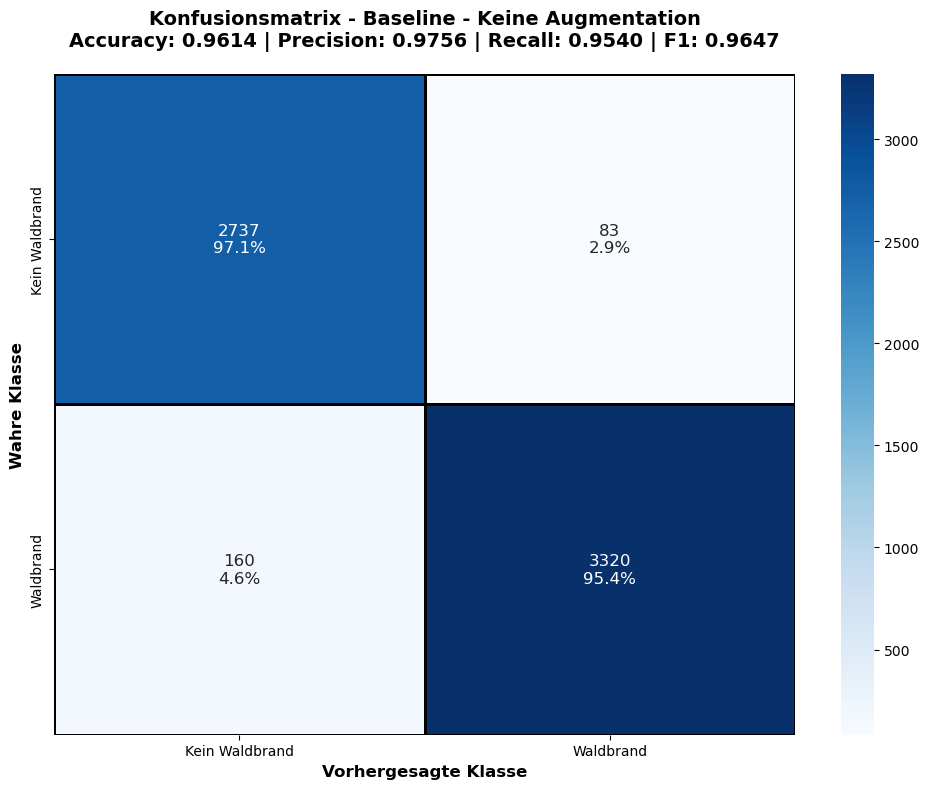


Klassifikationsmetriken:
Accuracy: 0.9614
Precision: 0.9756
Recall: 0.9540
F1-Score: 0.9647


In [21]:
# Modell evaluieren (Loss, Accuracy etc.)
# eval_results = baseline.evaluate(test_generator_standard, verbose=1)

# Vorhersagen für alle augmentierten Testbilder holen
predictions = baseline.predict(test_generator_standard)

# Binär-Klassifikation: Threshold 0.5
y_pred = (predictions.flatten() > 0.5).astype(int)

# Wahre Labels passend holen
y_true = test_generator_standard.y

plot_confusion_matrix(y_true, y_pred, title="Konfusionsmatrix - Baseline - Keine Augmentation")

 10/197 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

D:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
CM in der Funktion: [[2277  543]
 [ 111 3369]]


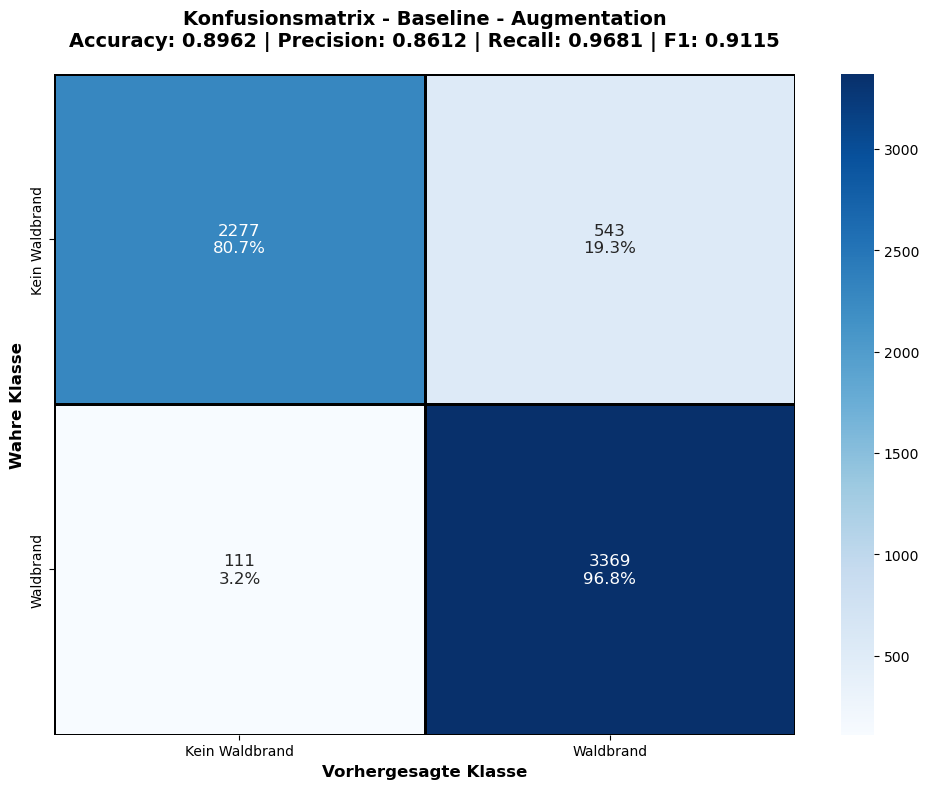


Klassifikationsmetriken:
Accuracy: 0.8962
Precision: 0.8612
Recall: 0.9681
F1-Score: 0.9115


In [22]:
# Modell evaluieren (Loss, Accuracy etc.)
# eval_results = baseline.evaluate(test_generator_augmented, verbose=1)

# Vorhersagen für alle augmentierten Testbilder holen
predictions = baseline.predict(test_generator_augmented)

# Binär-Klassifikation: Threshold 0.5
y_pred = (predictions.flatten() > 0.5).astype(int)

# Wahre Labels passend holen
y_true = test_generator_augmented.y

plot_confusion_matrix(y_true, y_pred, title="Konfusionsmatrix - Baseline - Augmentation")

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CM in der Funktion: [[2772   48]
 [ 319 3161]]


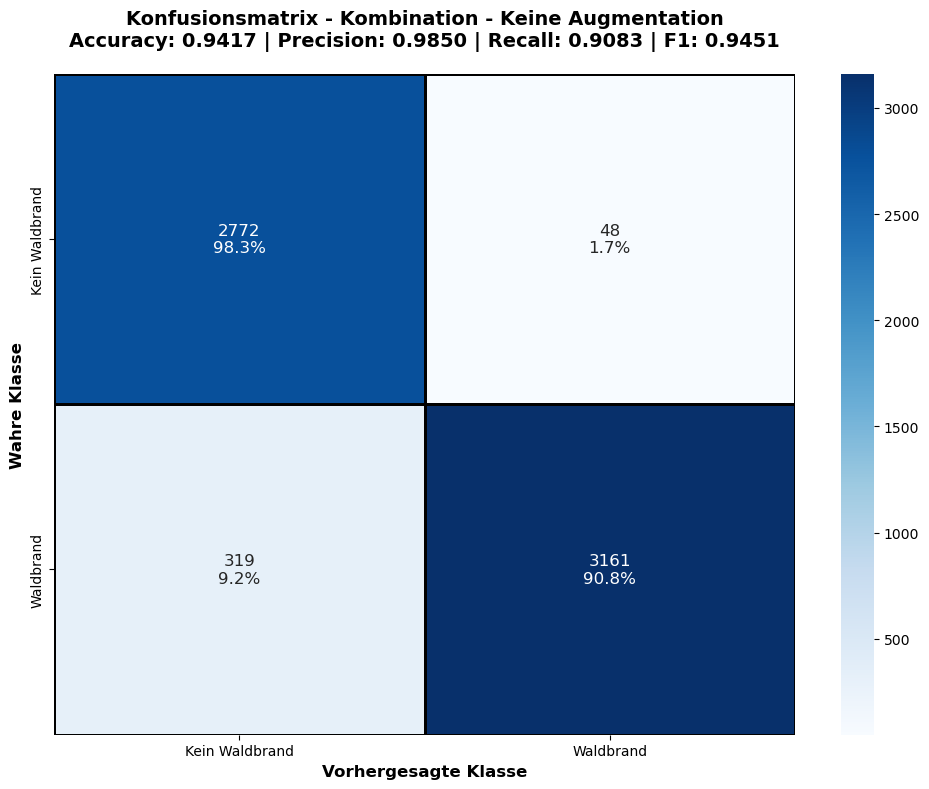


Klassifikationsmetriken:
Accuracy: 0.9417
Precision: 0.9850
Recall: 0.9083
F1-Score: 0.9451


In [24]:
# Modell evaluieren (Loss, Accuracy etc.)
# eval_results = combination.evaluate(test_generator_standard, verbose=1)

# Vorhersagen für alle augmentierten Testbilder holen
predictions = combination.predict(test_generator_standard)

# Binär-Klassifikation: Threshold 0.5
y_pred = (predictions.flatten() > 0.5).astype(int)

# Wahre Labels passend holen
y_true = test_generator_standard.y

plot_confusion_matrix(y_true, y_pred, title="Konfusionsmatrix - Kombination - Keine Augmentation")

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
CM in der Funktion: [[2700  120]
 [ 125 3355]]


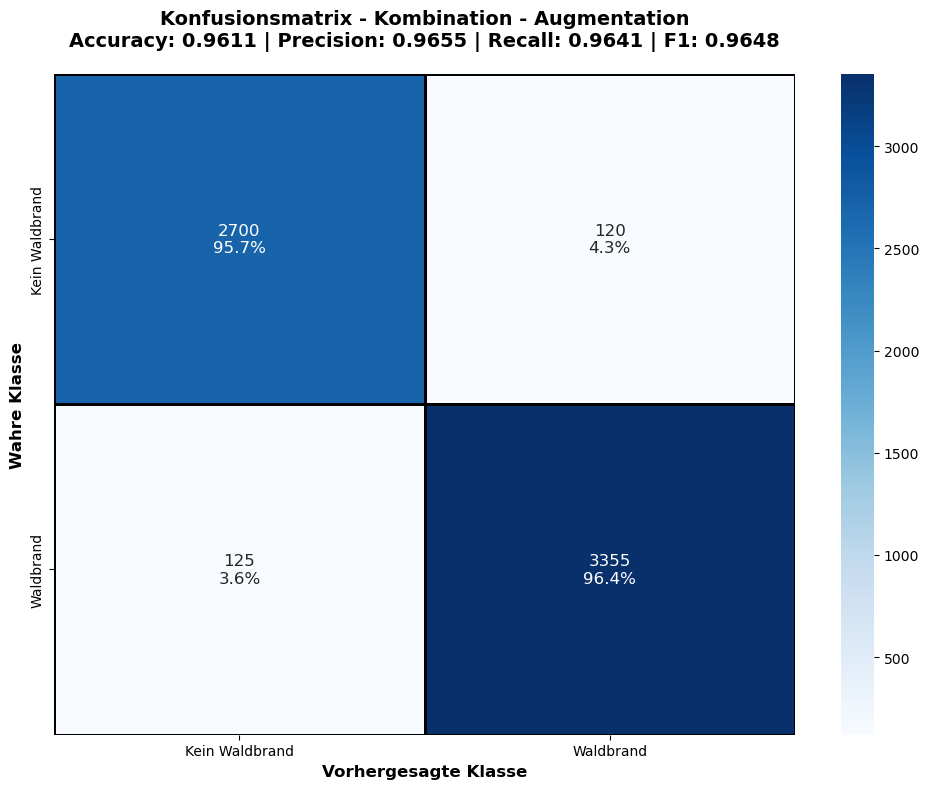


Klassifikationsmetriken:
Accuracy: 0.9611
Precision: 0.9655
Recall: 0.9641
F1-Score: 0.9648


In [29]:
# Modell evaluieren (Loss, Accuracy etc.)
# eval_results = combination.evaluate(test_generator_augmented, verbose=1)

# Vorhersagen für alle augmentierten Testbilder holen
predictions = combination.predict(test_generator_augmented)

# Binär-Klassifikation: Threshold 0.5
y_pred = (predictions.flatten() > 0.5).astype(int)

# Wahre Labels passend holen
y_true = test_generator_augmented.y

plot_confusion_matrix(y_true, y_pred, title="Konfusionsmatrix - Kombination - Augmentation")

___